# Part 1 - Sentiment Analysis with a from-scratch Transformer

### 1. Introduction

This report presents the first part of the project: development and evaluation of a from-scratch transformer-based sentiment classifier in PyTorch. The objective is to compare the transformer model against a simple LSTM baseline on a five-class sentiment analysis task using the Amazon Reviews Multi-English dataset.

### 2. Imports and Settings

This section defines all project paths, imports and training hyperparameters used throughout the notebook. Centralizing configuration values improves reproducibility and makes experiments easier to manage.

In [31]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import re
from datasets import load_dataset
import math
import argparse
import csv
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR = RESULTS_DIR / "plots"

TRAIN_PATH = DATA_DIR / 'amazon_reviews_multi_en_train.jsonl'
VAL_PATH = DATA_DIR / 'amazon_reviews_multi_en_validation.jsonl'
TEST_PATH = DATA_DIR / 'amazon_reviews_multi_en_test.jsonl'

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 5 
MAX_LENGTH = 128 

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR)
print('TRAIN_PATH exists:', TRAIN_PATH.exists())
print('VAL_PATH exists:', VAL_PATH.exists())
print('TEST_PATH exists:', TEST_PATH.exists())

PROJECT_ROOT: g:\SentimentAnalysisCUDA\Sentiment-Analysis
DATA_DIR: g:\SentimentAnalysisCUDA\Sentiment-Analysis\data\raw
TRAIN_PATH exists: True
VAL_PATH exists: True
TEST_PATH exists: True


### 3. Data download

The dataset used in this project is the Amazon Reviews Multi (English) dataset, which contains real customer reviews collected from Amazon. Each review consists of a text input and a corresponding sentiment label derived from the product rating.

The dataset is split into three subsets:

- Training set - used for model learning,
- Validation set - used for hyperparameter tuning and monitoring overfitting,
- Test set - used for final evaluation of model performance.

In [12]:
if TRAIN_PATH.exists() and TEST_PATH.exists() and VAL_PATH.exists():
    print("Dataset already prepared. Skipping download.")
else:
    print("Downloading dataset...")
    dataset = load_dataset("SetFit/amazon_reviews_multi_en")
    TRAIN_PATH.parent.mkdir(parents=True, exist_ok=True)
    with TRAIN_PATH.open("w", encoding="utf-8") as f:
        for x in dataset["train"]:
            f.write(json.dumps(x) + "\n")
    with TEST_PATH.open("w", encoding="utf-8") as f:
        for x in dataset["test"]:
            f.write(json.dumps(x) + "\n")
    with VAL_PATH.open("w", encoding="utf-8") as f:
        for x in dataset["validation"]:
            f.write(json.dumps(x) + "\n")

Dataset already prepared. Skipping download.


### 4. Dataset Analysis

After loading and converting the data into a structured format, the dataset consists of:

- Text: raw user review written in natural language
- Label: sentiment class (0–4)

Each split (train, validation, test) follows the same structure, which ensures consistency across the entire pipeline.

In [22]:
def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

train_df = load_jsonl(TRAIN_PATH)
val_df = load_jsonl(VAL_PATH)
test_df = load_jsonl(TEST_PATH)

# Data shape
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Class distribution
print("\n--- Label distribution: --- ")
print(train_df["label"].value_counts().sort_index())

# Text length analysis
train_df["text_length"] = train_df["text"].apply(lambda x: len(str(x).split()))

print("\n--- Text length stats: ---")
print(train_df["text_length"].describe())

# Sample reviews
print("\n--- Sample reviews ---")
for i in {0, 99999, 199999}:
    print(train_df["text"].iloc[i])
    print("Label:", train_df["label"].iloc[i])
    print("---")

Train shape: (200000, 4)
Validation shape: (5000, 4)
Test shape: (5000, 4)

--- Label distribution: --- 
label
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64

--- Text length stats: ---
count    200000.000000
mean         34.114000
std          34.201068
min           1.000000
25%          12.000000
50%          24.000000
75%          44.000000
max         769.000000
Name: text_length, dtype: float64

--- Sample reviews ---
Arrived broken. Manufacturer defect. Two of the legs of the base were not completely formed, so there was no way to insert the casters. I unpackaged the entire chair and hardware before noticing this. So, I'll spend twice the amount of time boxing up the whole useless thing and send it back with a 1-star review of part of a chair I never got to sit in. I will go so far as to include a picture of what their injection molding and quality assurance process missed though. I will be hesitant to buy again. It makes me wonder if there aren

##### Dataset size
The dataset consists of:
- Training set: 200,000 samples
- Validation set: 5,000 samples
- Test set: 5,000 samples

The training set is significantly larger than validation and test sets, which is beneficial for stable model learning and generalization.

##### Class distribution
Each review is labeled with one of five sentiment classes (0–4), representing a star rating scale. The dataset is perfectly balanced - each class has 40,000 samples. This distribution ensures that the model does not develop bias toward any specific sentiment class.

##### Text length
The analysis of review lengths shows:
- Average length: ~34 words
- Median length: 24 words
- Minimum length: 1 word
- Maximum length: 769 words

Most reviews are relatively short, with 50% of samples containing fewer than 24 words. However, there are some long outliers, reaching up to 769 words. The distribution is strongly right-skewed, meaning that short reviews dominate the dataset.

##### Implications for model design

Based on the text length distribution, a fixed maximum sequence length of 128 tokens is sufficient to cover the majority of samples
Most reviews fall well below this limit (75% ≤ 44 words)
Only a small fraction of long reviews will be truncated

This trade-off ensures efficient training while preserving most of the meaningful content.

##### Qualitative observations

Sample reviews show a wide variety of writing styles:

- Very negative reviews often contain complaints about product defects or dissatisfaction
- Neutral reviews may express uncertainty or partial satisfaction
- Positive reviews are short and expressive, often focusing on simple praise

##### Summary
The dataset is:
- Large-scale and well-balanced
- Rich in linguistic variation
- Dominated by short texts with occasional long reviews

These characteristics make it well-suited for Transformer-based classification, while also providing enough complexity to evaluate the model’s ability to capture contextual sentiment patterns.

### 5. Dataset Implementation

To prepare textual data for training a Transformer model, a custom PyTorch Dataset class was implemented. Its role is to:
- load raw JSONL data,
- tokenize text,
- build vocabulary,
- convert text into numerical form,
- ensure fixed sequence length via padding/truncation.

This allows the model to process text as tensors instead of raw strings.

In [25]:
class AmazonSentimentDataset(Dataset):
    def __init__(self, file_path, vocab=None, max_length=128):
        self.max_length = max_length
        self.data = []
        
        # Load data from file
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                item = json.loads(line)
                self.data.append({
                    'text': item['text'].lower(),   # Review text converted to lowercase
                    'label': int(item['label'])     # Rating label (0-4)
                })

        # Build vocabulary
        if vocab is None:
            self.vocab = self.build_vocab()
        else:
            self.vocab = vocab

        self.pad_token_id = self.vocab.get('<PAD>', 0)  # Padding token ID
        self.unk_token_id = self.vocab.get('<UNK>', 1)  # Unknown token ID for out-of-vocabulary words

    def build_vocab(self):
        words = []
        for item in self.data:
            words.extend(self.tokenize(item['text']))
        
        counter = Counter(words)
        common_words = counter.most_common(10000) # Limit vocabulary to the 10k most frequent words
        
        # Map words to unique IDs
        vocab = {'<PAD>': 0, '<UNK>': 1}
        for i, (word, _) in enumerate(common_words):
            vocab[word] = i + 2
        return vocab

    # Split text into individual words/tokens
    def tokenize(self, text):
        return re.findall(r'\w+', text)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = self.tokenize(item['text'])
        
        # Convert tokens to their respective vocabulary IDs
        ids = [self.vocab.get(token, self.unk_token_id) for token in tokens]
        
        # Pad or truncate the sequence to match max_length
        if len(ids) < self.max_length:
            ids += [self.pad_token_id] * (self.max_length - len(ids))
        else:
            ids = ids[:self.max_length]
        
        # Return PyTorch tensors for word IDs and the corresponding label
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'label': torch.tensor(item['label'], dtype=torch.long)
        }

### 6. Models

To evaluate the effectiveness of different approaches to sentiment classification, two models were implemented and trained on the same dataset. The goal was to compare a custom-built Transformer architecture with a baseline neural model in terms of performance and learning capability.

##### LSTM Baseline

A Long Short-Term Memory (LSTM) network was implemented as a baseline model for sentiment classification. It processes text sequentially, maintaining a hidden state that captures information from previous tokens.

The model consists of three main components: an embedding layer that converts token IDs into dense vectors, an LSTM layer that models temporal dependencies in the sequence, and a fully connected layer that maps the final hidden state to sentiment class logits.

The final hidden state of the LSTM is used as a summary representation of the entire input sequence for classification. This model provides a simpler alternative to Transformer-based architectures and serves as a reference point for performance comparison.

In [27]:
class LSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        # Embedding layer: maps token IDs to dense vectors, ignoring padding tokens (ID 0)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM layer: processes word vectors sequentially
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, num_layers=1)
        
        # Fully connected layer: maps the final hidden state to class logits
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text):
        # Pass token IDs through the embedding layer to get word vectors
        embedded = self.embedding(text)
        
        # Forward propagate through LSTM to get outputs and hidden states
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Extract the final hidden state of the last LSTM layer
        last_hidden = hidden[-1]
        
        # Map the hidden representation to output class probabilities (logits)
        return self.fc(last_hidden)

#### Transformer

A custom Transformer encoder was implemented in PyTorch for sentiment classification. The model is designed to capture contextual relationships in text using self-attention, and it is compared against an LSTM baseline.

##### Input representation
The input consists of token embeddings combined with positional embeddings, which provide information about word meaning and order in the sequence.

##### Self-attention mechanism
The core of the model is multi-head self-attention, which allows each token to attend to all other tokens in the sequence. Padding tokens are masked to ensure they do not influence the output.

##### Encoder layers
The model is composed of stacked Transformer encoder layers, each containing:
- multi-head self-attention
- feed-forward network
- residual connections and layer normalization

This improves training stability and representation quality.

##### Output representation
Instead of using a single token, the model applies mean pooling over valid tokens to obtain a fixed-size sequence representation. This vector is then passed to a linear layer for classification into 5 sentiment classes.

In [29]:
class ScaledDotProductAttention(nn.Module):
	def __init__(self, dropout=0.0):
		super().__init__()
		self.dropout = nn.Dropout(dropout)

	def forward(self, q, k, v, mask=None):
		# q,k,v: (batch, heads, seq_len, head_dim)
		d_k = q.size(-1)
		scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
		if mask is not None:
			scores = scores.masked_fill(mask == 0, float('-1e9'))
		attn = torch.softmax(scores, dim=-1)
		attn = self.dropout(attn)
		out = torch.matmul(attn, v)
		return out, attn

class MultiHeadAttention(nn.Module):
	def __init__(self, embed_dim, num_heads, dropout=0.0):
		super().__init__()
		assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
		self.embed_dim = embed_dim
		self.num_heads = num_heads
		self.head_dim = embed_dim // num_heads

		self.q_proj = nn.Linear(embed_dim, embed_dim)
		self.k_proj = nn.Linear(embed_dim, embed_dim)
		self.v_proj = nn.Linear(embed_dim, embed_dim)
		self.out_proj = nn.Linear(embed_dim, embed_dim)
		self.attention = ScaledDotProductAttention(dropout=dropout)

	def forward(self, x, key_padding_mask=None):
		# x: (batch, seq_len, embed_dim)
		batch_size, seq_len, _ = x.size()

		q = self.q_proj(x)
		k = self.k_proj(x)
		v = self.v_proj(x)

		q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
		k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
		v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

		if key_padding_mask is not None:
			mask = key_padding_mask.unsqueeze(1).unsqueeze(1)
		else:
			mask = None

		attn_out, attn = self.attention(q, k, v, mask=mask)

		attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)
		out = self.out_proj(attn_out)
		return out

class FeedForward(nn.Module):
	def __init__(self, embed_dim, hidden_dim, dropout=0.0):
		super().__init__()
		self.fc1 = nn.Linear(embed_dim, hidden_dim)
		self.fc2 = nn.Linear(hidden_dim, embed_dim)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		x = self.fc1(x)
		x = F.gelu(x)
		x = self.dropout(x)
		x = self.fc2(x)
		return x

class TransformerEncoderLayer(nn.Module):
	def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.0):
		super().__init__()
		self.self_attn = MultiHeadAttention(embed_dim, num_heads, dropout=dropout)
		self.norm1 = nn.LayerNorm(embed_dim)
		self.ff = FeedForward(embed_dim, ff_hidden_dim, dropout=dropout)
		self.norm2 = nn.LayerNorm(embed_dim)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x, key_padding_mask=None):
		# Self-attention + Add&Norm
		attn_out = self.self_attn(x, key_padding_mask=key_padding_mask)
		x = x + self.dropout(attn_out)
		x = self.norm1(x)

		# Feed-forward + Add&Norm
		ff_out = self.ff(x)
		x = x + self.dropout(ff_out)
		x = self.norm2(x)
		return x

class TransformerEncoder(nn.Module):
	def __init__(self, num_layers, embed_dim, num_heads, ff_hidden_dim, dropout=0.0):
		super().__init__()
		self.layers = nn.ModuleList([
			TransformerEncoderLayer(embed_dim, num_heads, ff_hidden_dim, dropout=dropout)
			for _ in range(num_layers)
		])

	def forward(self, x, key_padding_mask=None):
		for layer in self.layers:
			x = layer(x, key_padding_mask=key_padding_mask)
		return x

class TransformerSentimentModel(nn.Module):
	def __init__(self, vocab_size, embed_dim=128, num_heads=8, ff_hidden_dim=512, num_layers=2, output_dim=5, max_length=128, dropout=0.1):
		super().__init__()
		self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
		self.pos_embed = nn.Embedding(max_length, embed_dim)
		self.encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_hidden_dim, dropout=dropout)
		self.dropout = nn.Dropout(dropout)
		self.fc = nn.Linear(embed_dim, output_dim)
		self.max_length = max_length

	def forward(self, input_ids):
		# input_ids: (batch, seq_len)
		batch_size, seq_len = input_ids.size()
		if seq_len > self.max_length:
			raise ValueError(f"Sequence length {seq_len} exceeds max_length {self.max_length}")

		token_emb = self.embed(input_ids) 
		positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
		pos_emb = self.pos_embed(positions)

		x = token_emb + pos_emb

		# key padding mask: 1 for real tokens, 0 for padding
		key_padding_mask = (input_ids != 0).to(input_ids.device)

		x = self.encoder(x, key_padding_mask=key_padding_mask)

		# mean pooling over real tokens
		mask = key_padding_mask.unsqueeze(-1)  # (batch, seq_len, 1)
		summed = (x * mask).sum(dim=1)  # (batch, embed_dim)
		denom = mask.sum(dim=1).clamp(min=1).to(x.dtype)
		pooled = summed / denom

		pooled = self.dropout(pooled)
		logits = self.fc(pooled)
		return logits


__all__ = ["TransformerSentimentModel"]


The Transformer model provides a parallel, attention-based alternative to sequential models like LSTM. It is expected to better capture global context in text and improve classification performance.

### 7. Training Procedure

The training pipeline supports both the LSTM baseline and the Transformer model, enabling direct comparison under identical conditions.

The dataset is loaded using a custom Dataset class and passed to DataLoader objects, with shuffling applied to the training set. A shared vocabulary built from the training data is used for both training and validation.

Each training epoch consists of a forward pass, loss computation using cross-entropy, backpropagation, and parameter updates using the Adam optimizer. Model performance is evaluated after each epoch using validation loss and accuracy.

The model with the best validation loss is saved as a checkpoint. Additionally, all training metrics are stored for later analysis and visualization. Hyperparameters and configuration details are saved to ensure reproducibility of experiments.

In [39]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one full epoch over the dataset."""
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    for batch in dataloader:
        # Move batch data to the designated device (CPU or GPU)
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        
        # Reset gradients from the previous step
        optimizer.zero_grad()
        
        # Compute predicted outputs by passing inputs to the model
        outputs = model(input_ids)
        
        # Calculate the batch loss
        loss = criterion(outputs, labels)
        
        # Compute gradient of the loss with respect to model parameters
        loss.backward()
        
        # Perform a single optimization step to update weights
        optimizer.step()
        
        # Accumulate metrics
        total_loss += loss.item() * input_ids.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_predictions += torch.sum(preds == labels).item()
        total_samples += input_ids.size(0)
        
    return total_loss / total_samples, correct_predictions / total_samples

def evaluate(model, dataloader, criterion, device):
    """Evaluates the model performance on the validation/test set."""
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    # Disable gradient computation to save memory and accelerate computation
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            # Compute predicted outputs by passing inputs to the model
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            
            # Accumulate metrics
            total_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_samples += input_ids.size(0)
            
    return total_loss / total_samples, correct_predictions / total_samples

def train(args):
    # Automatically select GPU (CUDA) if available, otherwise fallback to CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Selected model: {args.model}")
    # Prepare run folder and output paths
    run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_name = args.run_name or f"{args.model}_{run_stamp}"
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    run_dir = RESULTS_DIR / run_name
    models_dir = run_dir / "models"
    metrics_path = run_dir / "metrics.csv"
    config_path = run_dir / "run_config.json"
    models_dir.mkdir(parents=True, exist_ok=True)

    # Resolve file paths using configuration
    print("Loading datasets...")
    train_file = DATA_DIR / "amazon_reviews_multi_en_train.jsonl"
    val_file = DATA_DIR / "amazon_reviews_multi_en_validation.jsonl"

    # Initialize Datasets
    train_dataset = AmazonSentimentDataset(train_file, max_length=MAX_LENGTH)
    val_dataset = AmazonSentimentDataset(val_file, vocab=train_dataset.vocab, max_length=MAX_LENGTH)

    # Initialize DataLoaders for batching and shuffling
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Extract dynamically built vocabulary size
    vocab_size = len(train_dataset.vocab)
    print(f"Vocabulary size: {vocab_size}")

    # Instantiate the selected model
    if args.model == "lstm":
        model = LSTMSentimentModel(
            vocab_size=vocab_size,
            embedding_dim=EMBEDDING_DIM,
            hidden_dim=HIDDEN_DIM,
            output_dim=OUTPUT_DIM,
        ).to(device)
    else:
        model = TransformerSentimentModel(
            vocab_size=vocab_size,
            embed_dim=EMBEDDING_DIM,
            num_heads=args.num_heads,
            ff_hidden_dim=args.ff_dim,
            num_layers=args.num_layers,
            output_dim=OUTPUT_DIM,
            max_length=MAX_LENGTH,
        ).to(device)

    # Define loss criteria and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # Save run configuration for reproducibility
    run_config = {
        "model": args.model,
        "num_heads": args.num_heads,
        "num_layers": args.num_layers,
        "ff_dim": args.ff_dim,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "embedding_dim": EMBEDDING_DIM,
        "hidden_dim": HIDDEN_DIM,
        "output_dim": OUTPUT_DIM,
        "max_length": MAX_LENGTH,
        "vocab_size": vocab_size,
        "train_file": str(train_file),
        "val_file": str(val_file),
    }
    config_path.write_text(json.dumps(run_config, indent=2), encoding="utf-8")
    # Prepare metrics CSV
    with metrics_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])

    # Core Training Loop
    print("Starting training...")
    best_val_loss = float("inf")
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}   | Val Acc: {val_acc*100:.2f}%")
        print("-" * 40)
        # Save metrics for this epoch
        with metrics_path.open("a", newline="", encoding="utf-8") as csv_file:
            writer = csv.writer(csv_file)
            writer.writerow([epoch + 1, train_loss, train_acc, val_loss, val_acc])
        # Save best model by validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = models_dir / "best_model.pt"
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "run_name": run_name,
            }, best_path)
            print(f"Saved best model to: {best_path}")

parser = argparse.ArgumentParser()
parser.add_argument("--model", choices=["lstm", "transformer"], default="lstm",
                    help="Which model to train: 'lstm' or 'transformer'")
parser.add_argument("--num-heads", type=int, default=8, help="Transformer: number of attention heads")
parser.add_argument("--num-layers", type=int, default=2, help="Transformer: number of encoder layers")
parser.add_argument("--ff-dim", type=int, default=512, help="Transformer: feed-forward hidden dim")
parser.add_argument("--run-name", type=str, default=None, help="Optional run name for saving outputs")
args = parser.parse_args(args=[])

### 8. Training Curves & Test Results
1. Tracking metrics

During training, the following metrics were recorded per epoch:
- training loss
- training accuracy
- validation loss
- validation accuracy

These values were saved in a CSV file and used to generate learning curves for both models.

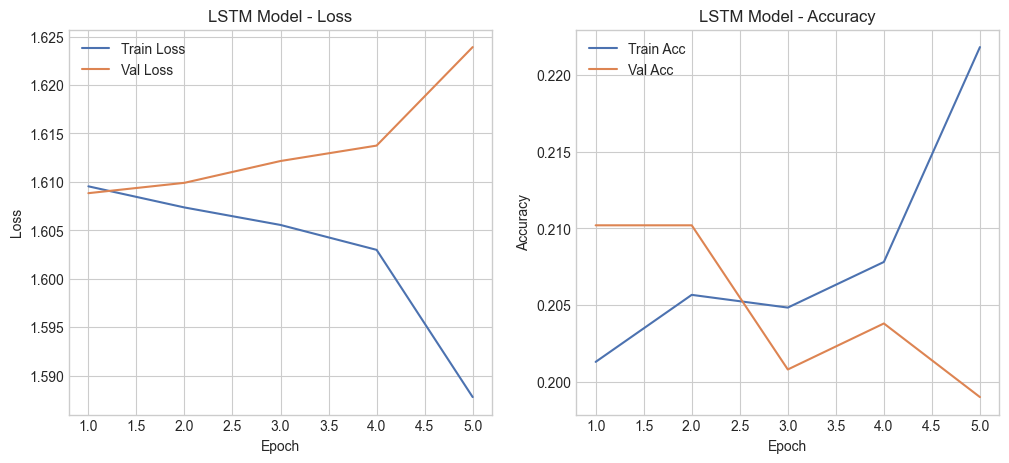

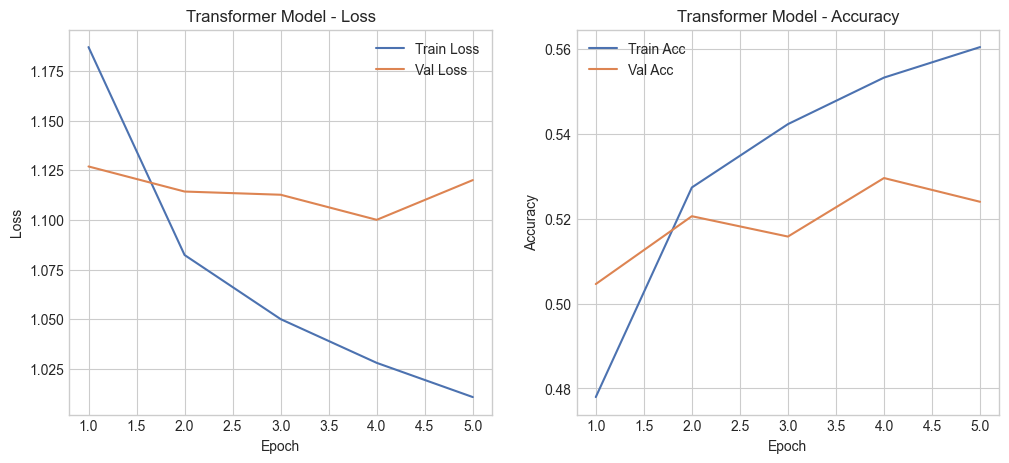

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_curves(csv_path, title):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(df["epoch"], df["train_acc"], label="Train Acc")
    plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_curves("../results/lstm_run_01/metrics.csv", "LSTM Model")
plot_curves("../results/transformer_run_01/metrics.csv", "Transformer Model")

##### LSTM
The LSTM model shows very weak learning dynamics:
- training loss decreases only slightly
- validation loss increases over time
- accuracy stays around ~20%, close to random performance (5 classes)

This indicates that the model fails to properly learn meaningful patterns from the data. The gap between training and validation performance suggests unstable generalization and limited model capacity for this task.

##### Transformer
The Transformer model shows significantly better learning behavior:
- training loss decreases steadily across epochs
- validation loss remains relatively stable with minor fluctuations
- accuracy improves consistently during training

Compared to LSTM, the Transformer demonstrates better optimization and stronger feature learning.

##### Overfitting Analysis
- LSTM: no real learning signal, slight overfitting pattern (train improves, val does not)
- Transformer: mild overfitting but generally stable training curves

The Transformer generalizes better due to self-attention capturing global context instead of relying on sequential memory.

##### Summary
The training curves clearly show that the Transformer model is significantly more effective for sentiment classification. It not only achieves higher accuracy but also demonstrates more stable and meaningful learning dynamics compared to the LSTM baseline.

In [49]:
def load_best_model(run_dir):
    with open(run_dir / "run_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    vocab_size = config["vocab_size"]
    if config["model"] == "lstm":
        model = LSTMSentimentModel(
            vocab_size=vocab_size,
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            output_dim=config["output_dim"],
        )
    else:
        model = TransformerSentimentModel(
            vocab_size=vocab_size,
            embed_dim=config["embedding_dim"],
            num_heads=config["num_heads"],
            ff_hidden_dim=config["ff_dim"],
            num_layers=config["num_layers"],
            output_dim=config["output_dim"],
            max_length=config["max_length"],
        )

    checkpoint = torch.load(run_dir / "models" / "best_model.pt", map_location="cpu", weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model.eval()


def evaluate_test(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch["input_ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


train_dataset = AmazonSentimentDataset(TRAIN_PATH, max_length=MAX_LENGTH)
test_dataset = AmazonSentimentDataset(TEST_PATH, vocab=train_dataset.vocab, max_length=MAX_LENGTH)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for run_name in ["lstm_run_01", "transformer_run_01"]:
    model = load_best_model(RESULTS_DIR / run_name)
    test_acc = evaluate_test(model, test_loader, device)
    print(f"{run_name}: test_accuracy={test_acc:.4f} on {len(test_dataset)} samples")

lstm_run_01: test_accuracy=0.2056 on 5000 samples
transformer_run_01: test_accuracy=0.5216 on 5000 samples


The experimental results show that the Transformer model achieved substantially better performance than the LSTM baseline on the test set. The Transformer reached an accuracy of 52.16%, while the LSTM baseline obtained 20.56%. This difference of more than 31 percentage points indicates a clear advantage of the attention-based architecture for this sentiment classification task.

The LSTM model, used here as a simple baseline, performed poorly. Its low accuracy suggests that the basic sequential architecture was not able to capture the relevant linguistic patterns in the dataset with sufficient effectiveness. In particular, the model appears to struggle with distinguishing among the five sentiment classes, which limits its practical usefulness for this task.

In contrast, the Transformer model demonstrated significantly stronger learning behavior. The higher test accuracy, together with more stable training dynamics, indicates that self-attention allows the model to represent contextual relationships between words more effectively than a recurrent model. This is especially important in sentiment analysis, where the meaning of a review often depends on the interaction of multiple words rather than on isolated tokens.

Overall, the results confirm that the Transformer is the more suitable model for this project. It provides better generalization, stronger classification performance, and a more convincing demonstration of the effectiveness of the proposed architecture compared with the LSTM baseline. 